In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import h5py
import time

In [2]:
class DeepFeedForward(object):
    def __init__(
            self,
            hidden_activation="relu",
            output_activation="sigmoid",
            print_cost=False,
            visualize_cost=False,
            epsilon=100,
            sigma=1e-12,
            seed=42
    ):

        self.hidden_activation = hidden_activation
        self.output_activation = output_activation
        self.print_cost = print_cost
        self.visualize_cost = visualize_cost
        self.epsilon = epsilon
        self.sigma = sigma
        self.seed = seed

        self.cost_ = []
        self.time_ = []
        self.costs = []
        self.times = []
        self.parameters = {}
        self.train_predict = None
        self.validation_predict = None
        self.test_predict = None

    def layer_sizes(self, X, Y, num_hidden_units):

        num_input_units = [X.shape[0]]
        num_output_units = [Y.shape[0]]
        num_hidden_units = list(num_hidden_units)

        layer_dimensions = list(num_input_units + num_hidden_units + num_output_units)

        return layer_dimensions

    def initialize_parameters(self, layer_dimensions):

        np.random.seed(self.seed)
        parameters = {}
        for l in range(1, len(layer_dimensions)):

            parameters[f"W{l}"] = np.random.randn(layer_dimensions[l], layer_dimensions[l-1]) / np.sqrt(layer_dimensions[l-1])
            parameters[f"b{l}"] = np.zeros((layer_dimensions[l], 1))

        return parameters

    def sigmoid(self, Z):

        A = 1 / (1 + np.exp(-Z))
        cache = Z

        return A, cache

    def relu(self, Z):

        A = np.maximum(0, Z)
        cache = Z

        return A, cache

    def sigmoid_backward(self, dA, cache):

        Z = cache
        S = 1 / (1 + np.exp(-Z))
        dZ = dA * S * (1 - S)

        assert (dZ.shape == Z.shape)

        return dZ

    def relu_backward(self, dA, cache):

        Z = cache
        dZ = np.array(dA, copy=True)
        dZ[Z <= 0] = 0

        assert (dZ.shape == Z.shape)

        return dZ

    def linear_forward(self, A, W, b):

        Z = np.dot(W, A) + b

        cache = (A, W, b)

        return Z, cache

    def linear_activation_forward(self, A_prev, W, b, activation):

        if activation == "sigmoid":

            Z, linear_cache = self.linear_forward(A=A_prev, W=W, b=b)
            A, activation_cache = self.sigmoid(Z=Z)

        elif activation == "relu":

            Z, linear_cache = self.linear_forward(A=A_prev, W=W, b=b)
            A, activation_cache = self.relu(Z=Z)

        cache = (linear_cache, activation_cache)

        return A, cache

    def forward_propagation(self, X, parameters, hidden_activation, output_activation):

        caches = []
        A = X
        L = len(parameters) // 2

        for l in range(1, L):
            A_prev = A

            A, cache = self.linear_activation_forward(
                A_prev=A_prev,
                W=parameters[f"W{l}"],
                b=parameters[f"b{l}"],
                activation=hidden_activation
            )
            caches.append(cache)

        A, cache = self.linear_activation_forward(
            A_prev=A,
            W=parameters[f"W{L}"],
            b=parameters[f"b{L}"],
            activation=output_activation
        )
        caches.append(cache)

        return A, caches

    def compute_cost(self, A, Y, sigma):

        m = Y.shape[1]

        cost = - np.sum(np.multiply(Y, np.log(A+sigma)) + np.multiply(1 - Y, np.log(1 - A+sigma))) / m

        cost = np.squeeze(cost)

        return cost


    def linear_backward(self, dZ, cache):

        A_prev, W, b = cache
        m = A_prev.shape[1]

        dW = np.dot(dZ, A_prev.T) / m
        db = np.sum(dZ, axis=1, keepdims=True) / m
        dA_prev = np.dot(W.T, dZ)

        return dA_prev, dW, db

    def linear_activation_backward(self, dA, cache, activation):

        linear_cache, activation_cache = cache

        if activation == "relu":

            dZ = self.relu_backward(
                dA=dA,
                cache=activation_cache
            )
            dA_prev, dW, db = self.linear_backward(
                dZ=dZ,
                cache=linear_cache
            )

        elif activation == "sigmoid":

            dZ = self.sigmoid_backward(
                dA=dA,
                cache=activation_cache
            )
            dA_prev, dW, db = self.linear_backward(
                dZ=dZ,
                cache=linear_cache
            )

        return dA_prev, dW, db

    def backward_propagation(self, A, Y, caches, hidden_activation, output_activation):

        grads = {}
        L = len(caches)
        Y = Y.reshape(A.shape)

        dA = - (np.divide(Y, A) - np.divide(1 - Y, 1 - A))

        current_cache = caches[-1]
        dA_prev, dW, db = self.linear_activation_backward(
            dA=dA,
            cache=current_cache,
            activation=output_activation
        )

        grads[f"dA{L-1}"] = dA_prev
        grads[f"dW{L}"] = dW
        grads[f"db{L}"] = db

        for l in reversed(range(L - 1)):

            current_cache = caches[l]

            dA_prev, dW, db = self.linear_activation_backward(
                dA=grads[f"dA{l+1}"],
                cache=current_cache,
                activation=hidden_activation
            )

            grads[f"dA{l}"] = dA_prev
            grads[f"dW{l+1}"] = dW
            grads[f"db{l+1}"] = db

        return grads

    def update_parameters(self, params, grads, learning_rate):

        parameters = copy.deepcopy(params)
        L = len(parameters) // 2

        for l in range(L):
            parameters[f"W{l+1}"] -= learning_rate * grads[f"dW{l+1}"]
            parameters[f"b{l+1}"] -= learning_rate * grads[f"db{l+1}"]

        return parameters

    def predict(self, X, parameters, hidden_activation, output_activation):

        m = X.shape[1]
        predicted = np.zeros((1, m))

        probabilities, caches = self.forward_propagation(
            X=X,
            parameters=parameters,
            hidden_activation=hidden_activation,
            output_activation=output_activation
        )

        predicted[0, :] = (probabilities > 0.5)

        return predicted

    def accuracy(self, predicted, Y):
        m = Y.shape[1]
        accuracy = np.sum((predicted == Y) / m)
        return accuracy

    def train(self, X, Y, num_hidden_units, hidden_activation, output_activation, epochs, learning_rate):

        layer_dimensions = self.layer_sizes(X, Y, num_hidden_units)
        parameters = self.initialize_parameters(layer_dimensions)

        for i in range(epochs):

            start = time.time()

            A, caches = self.forward_propagation(
                X=X,
                parameters=parameters,
                hidden_activation=hidden_activation,
                output_activation=output_activation
            )

            cost = self.compute_cost(A=A, Y=Y, sigma=self.sigma)
            self.costs.append(cost)

            grads = self.backward_propagation(
                A=A,
                Y=Y,
                caches=caches,
                hidden_activation=hidden_activation,
                output_activation=output_activation
            )

            parameters = self.update_parameters(
                params=parameters,
                grads=grads,
                learning_rate=learning_rate
            )

            stop = time.time()
            duration = stop - start
            self.times.append(duration)

            if self.print_cost:
                if i % self.epsilon == 0 or i == epochs - 1:
                    print(f"Epoch: {i}; Cost: {cost}, Duration: {round(duration, 3)} S")
                    self.cost_.append(cost)
                    self.time_.append(duration)

        return parameters

    def nn_model(self, X_train, Y_train, num_hidden_units, X_validation=None, Y_validation=None, X_test=None,
                 Y_test=None, hidden_activation="relu", output_activation="sigmoid", epochs=1000, learning_rate=1e-4,
                 accuracy=None
                 ):
        if self.print_cost:
            print("___"*23)
            print(f"NN_Model with {len(num_hidden_units)+1} layers; Number of Epochs: {epochs}; Learning Rate: {learning_rate}")
            print("___"*23)

        parameters = self.train(
            X=X_train,
            Y=Y_train,
            num_hidden_units=num_hidden_units,
            hidden_activation=hidden_activation,
            output_activation=output_activation,
            epochs=epochs,
            learning_rate=learning_rate
        )
        self.parameters = parameters

        if accuracy:
            print("__"*18)
            train_predict = self.predict(
                X=X_train,
                parameters=parameters,
                hidden_activation=hidden_activation,
                output_activation=output_activation
            )
            self.train_predict = train_predict
            train_accuracy = self.accuracy(
                predicted=train_predict,
                Y=Y_train
            )

            print(f"Train Accuracy: {train_accuracy}")

            if X_validation is not None and X_validation.any():

                validation_predict = self.predict(
                    X=X_validation,
                    parameters=parameters,
                    hidden_activation=hidden_activation,
                    output_activation=output_activation
                )
                self.validation_predict = validation_predict
                validation_accuracy = self.accuracy(
                    predicted=validation_predict,
                    Y=Y_validation
                )

                print(f"Validation Accuracy: {validation_accuracy}")

            if X_test is not None and X_test.any():
                test_predict = self.predict(
                    X=X_test,
                    parameters=parameters,
                    hidden_activation=hidden_activation,
                    output_activation=output_activation
                )
                self.test_predict = test_predict
                test_accuracy = self.accuracy(
                    predicted=test_predict,
                    Y=Y_test
                )

                print(f"Test Accuracy: {test_accuracy}")
                print("__" * 18)

            if self.visualize_cost:
                plt.figure(figsize=(8, 6))
                plt.plot(self.costs)
                plt.title("Epoch vs. Cost")
                plt.xlabel("Epoch")
                plt.ylabel("Cost")
                plt.show()

In [3]:
train_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_cat.h5", "r")
train_set_x_orig = np.array(train_dataset["train_set_x"][:])  # your train set features
train_set_y_orig = np.array(train_dataset["train_set_y"][:])  # your train set labels

test_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_cat.h5", "r")
test_set_x_orig = np.array(test_dataset["test_set_x"][:])  # your test set features
test_set_y_orig = np.array(test_dataset["test_set_y"][:])  # your test set labels

classes = np.array(test_dataset["list_classes"][:])  # the list of classes

train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

In [4]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
print(train_set_x_flatten.shape)
print(test_set_x_flatten.shape)


(12288, 209)
(12288, 50)


In [5]:
X_train = train_set_x_flatten / 255
Y_train = train_set_y_orig
X_test = test_set_x_flatten / 255
Y_test = test_set_y_orig
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(12288, 209)
(1, 209)
(12288, 50)
(1, 50)


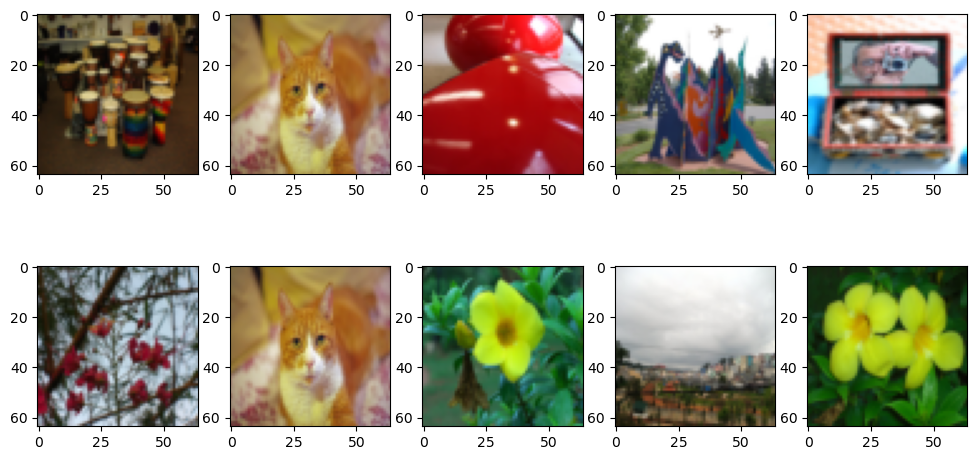

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(train_set_x_orig[5])
plt.subplot(2, 5, 2)
plt.imshow(train_set_x_orig[24])
plt.subplot(2, 5, 3)
plt.imshow(train_set_x_orig[103])
plt.subplot(2, 5, 4)
plt.imshow(train_set_x_orig[201])
plt.subplot(2, 5, 5)
plt.imshow(train_set_x_orig[15])
plt.subplot(2, 5, 6)
plt.imshow(train_set_x_orig[46])
plt.subplot(2, 5, 7)
plt.imshow(train_set_x_orig[24])
plt.subplot(2, 5, 8)
plt.imshow(train_set_x_orig[76])
plt.subplot(2, 5, 9)
plt.imshow(train_set_x_orig[17])
plt.subplot(2, 5, 10)
plt.imshow(train_set_x_orig[48])

plt.show()


_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.0001
_____________________________________________________________________
Epoch: 0; Cost: 0.6932195073562671, Duration: 0.026 S
Epoch: 200; Cost: 0.6925946360148801, Duration: 0.008 S
Epoch: 400; Cost: 0.6920264696609375, Duration: 0.008 S
Epoch: 600; Cost: 0.6914981998339268, Duration: 0.008 S
Epoch: 800; Cost: 0.6909763958894997, Duration: 0.008 S
Epoch: 1000; Cost: 0.6904582195974065, Duration: 0.008 S
Epoch: 1200; Cost: 0.6899458572017854, Duration: 0.008 S
Epoch: 1400; Cost: 0.6894393817368176, Duration: 0.008 S
Epoch: 1600; Cost: 0.6889417318906813, Duration: 0.009 S
Epoch: 1800; Cost: 0.688441012652529, Duration: 0.011 S
Epoch: 2000; Cost: 0.68794210678199, Duration: 0.012 S
Epoch: 2200; Cost: 0.6874493234675509, Duration: 0.008 S
Epoch: 2400; Cost: 0.686964198297282, Duration: 0.008 S
Epoch: 2600; Cost: 0.6864800521758538, Duration: 0.011 S
Epo

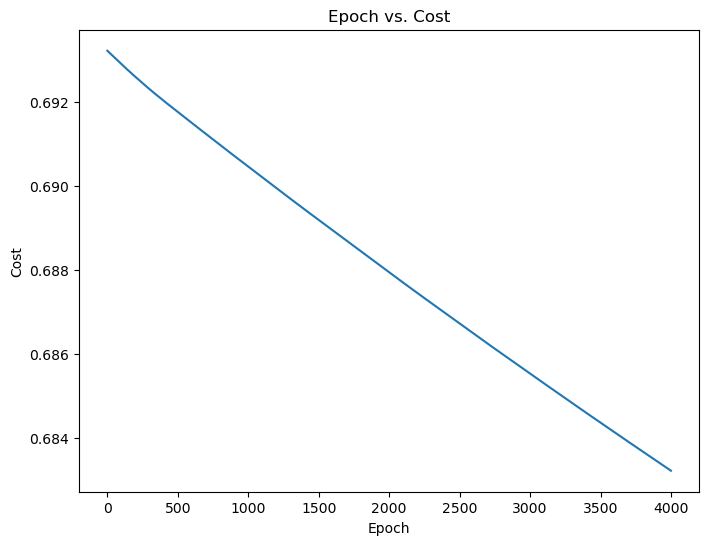

_____________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 4000; Learning Rate: 0.0001
_____________________________________________________________________
Epoch: 0; Cost: 0.693330159998475, Duration: 0.019 S
Epoch: 200; Cost: 0.6925247556182121, Duration: 0.01 S
Epoch: 400; Cost: 0.6918773315419735, Duration: 0.015 S
Epoch: 600; Cost: 0.6912663101599957, Duration: 0.014 S
Epoch: 800; Cost: 0.6906948306055166, Duration: 0.011 S
Epoch: 1000; Cost: 0.6901372652508233, Duration: 0.011 S
Epoch: 1200; Cost: 0.6895927620263166, Duration: 0.01 S
Epoch: 1400; Cost: 0.6890515023337519, Duration: 0.01 S
Epoch: 1600; Cost: 0.6885135870257106, Duration: 0.011 S
Epoch: 1800; Cost: 0.6879756301011022, Duration: 0.012 S
Epoch: 2000; Cost: 0.6874505556356504, Duration: 0.011 S
Epoch: 2200; Cost: 0.6869362172265626, Duration: 0.011 S
Epoch: 2400; Cost: 0.6864295750692135, Duration: 0.011 S
Epoch: 2600; Cost: 0.6859255217469099, Duration: 0.01 S
Epoc

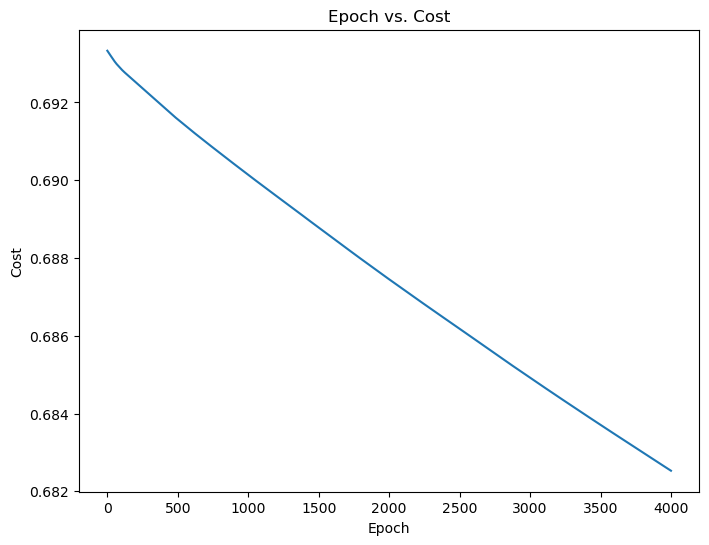

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.0001
_____________________________________________________________________
Epoch: 0; Cost: 0.675269223090208, Duration: 0.035 S
Epoch: 200; Cost: 0.6472371773482488, Duration: 0.013 S
Epoch: 400; Cost: 0.6396320755879221, Duration: 0.012 S
Epoch: 600; Cost: 0.633614019519904, Duration: 0.01 S
Epoch: 800; Cost: 0.6271917333969504, Duration: 0.01 S
Epoch: 1000; Cost: 0.6220425752328453, Duration: 0.01 S
Epoch: 1200; Cost: 0.6172035432289464, Duration: 0.01 S
Epoch: 1400; Cost: 0.6124809561375135, Duration: 0.01 S
Epoch: 1600; Cost: 0.607818405191856, Duration: 0.012 S
Epoch: 1800; Cost: 0.6033663457158085, Duration: 0.017 S
Epoch: 2000; Cost: 0.5991757329637728, Duration: 0.01 S
Epoch: 2200; Cost: 0.5950748404918721, Duration: 0.013 S
Epoch: 2400; Cost: 0.590958467871395, Duration: 0.01 S
Epoch: 2600; Cost: 0.5869918111488737, Duration: 0.01 S
Epoch: 2800

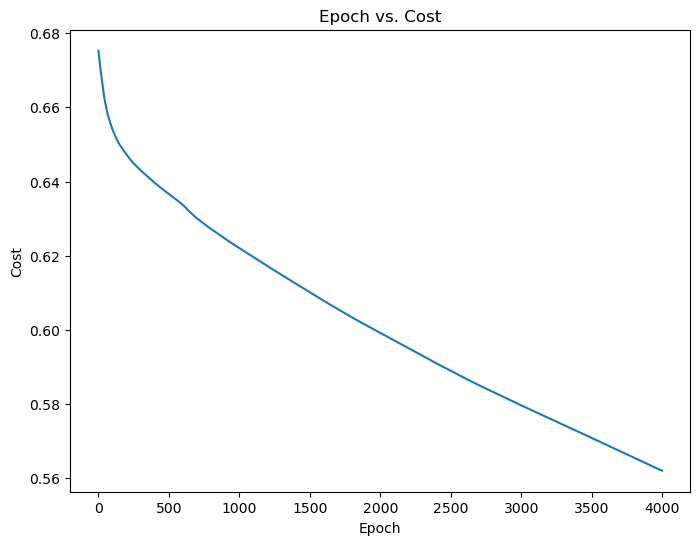

_____________________________________________________________________
NN_Model with 4 layers; Number of Epochs: 4000; Learning Rate: 0.0001
_____________________________________________________________________
Epoch: 0; Cost: 0.693244301489931, Duration: 0.017 S
Epoch: 200; Cost: 0.6927124443615119, Duration: 0.009 S
Epoch: 400; Cost: 0.6922193112718084, Duration: 0.009 S
Epoch: 600; Cost: 0.6917420434493369, Duration: 0.009 S
Epoch: 800; Cost: 0.691271585021482, Duration: 0.009 S
Epoch: 1000; Cost: 0.6908058000742724, Duration: 0.009 S
Epoch: 1200; Cost: 0.6903446419463729, Duration: 0.011 S
Epoch: 1400; Cost: 0.6898880644229561, Duration: 0.009 S
Epoch: 1600; Cost: 0.6894360217321438, Duration: 0.009 S
Epoch: 1800; Cost: 0.6889884685414566, Duration: 0.012 S
Epoch: 2000; Cost: 0.688545359954271, Duration: 0.009 S
Epoch: 2200; Cost: 0.6881091336809774, Duration: 0.009 S
Epoch: 2400; Cost: 0.6876780427064352, Duration: 0.009 S
Epoch: 2600; Cost: 0.6872512398111992, Duration: 0.01 S
Epo

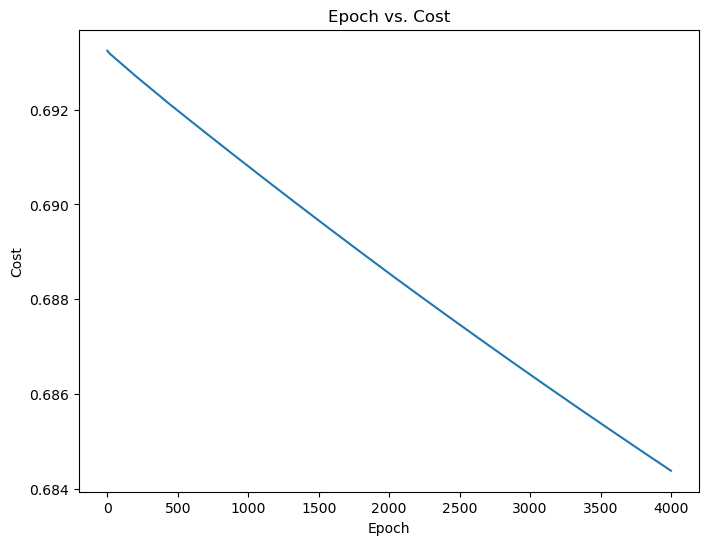

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.0005
_____________________________________________________________________
Epoch: 0; Cost: 0.6932195073562671, Duration: 0.014 S
Epoch: 200; Cost: 0.69045799814451, Duration: 0.008 S
Epoch: 400; Cost: 0.6879418602644417, Duration: 0.008 S
Epoch: 600; Cost: 0.685529865714162, Duration: 0.008 S
Epoch: 800; Cost: 0.6832162427778884, Duration: 0.01 S
Epoch: 1000; Cost: 0.6810066463852751, Duration: 0.008 S
Epoch: 1200; Cost: 0.678919921397925, Duration: 0.008 S
Epoch: 1400; Cost: 0.6769386342823417, Duration: 0.009 S
Epoch: 1600; Cost: 0.6750397634014788, Duration: 0.01 S
Epoch: 1800; Cost: 0.673227661942212, Duration: 0.011 S
Epoch: 2000; Cost: 0.6714860630893931, Duration: 0.008 S
Epoch: 2200; Cost: 0.6698115738584671, Duration: 0.01 S
Epoch: 2400; Cost: 0.6681877427834187, Duration: 0.01 S
Epoch: 2600; Cost: 0.6665875679508244, Duration: 0.008 S
Epoch: 2

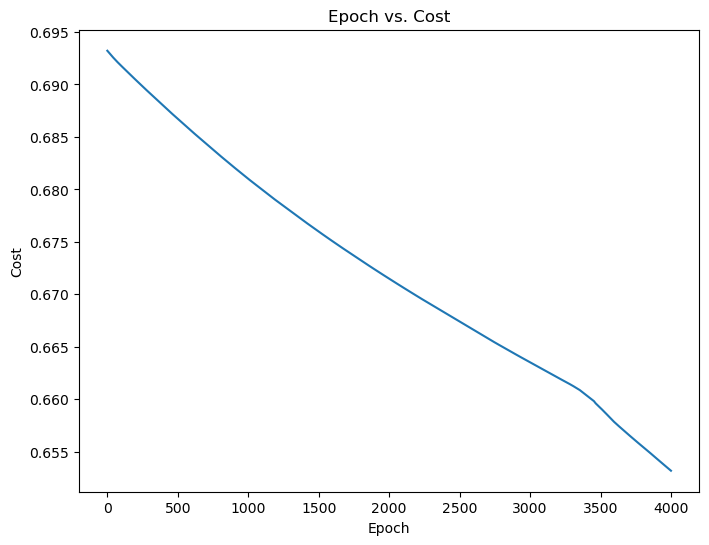

_____________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 4000; Learning Rate: 0.0005
_____________________________________________________________________
Epoch: 0; Cost: 0.693330159998475, Duration: 0.027 S
Epoch: 200; Cost: 0.6901366744673613, Duration: 0.01 S
Epoch: 400; Cost: 0.6874497279811089, Duration: 0.011 S
Epoch: 600; Cost: 0.6849190541518737, Duration: 0.01 S
Epoch: 800; Cost: 0.6825264474875442, Duration: 0.011 S
Epoch: 1000; Cost: 0.6802388506715737, Duration: 0.01 S
Epoch: 1200; Cost: 0.6780385624345261, Duration: 0.011 S
Epoch: 1400; Cost: 0.6759188449750612, Duration: 0.011 S
Epoch: 1600; Cost: 0.673869851893676, Duration: 0.011 S
Epoch: 1800; Cost: 0.6718794079375181, Duration: 0.011 S
Epoch: 2000; Cost: 0.669971481207127, Duration: 0.011 S
Epoch: 2200; Cost: 0.6681184138330065, Duration: 0.011 S
Epoch: 2400; Cost: 0.666311059007282, Duration: 0.01 S
Epoch: 2600; Cost: 0.6645457979984206, Duration: 0.012 S
Epoch: 

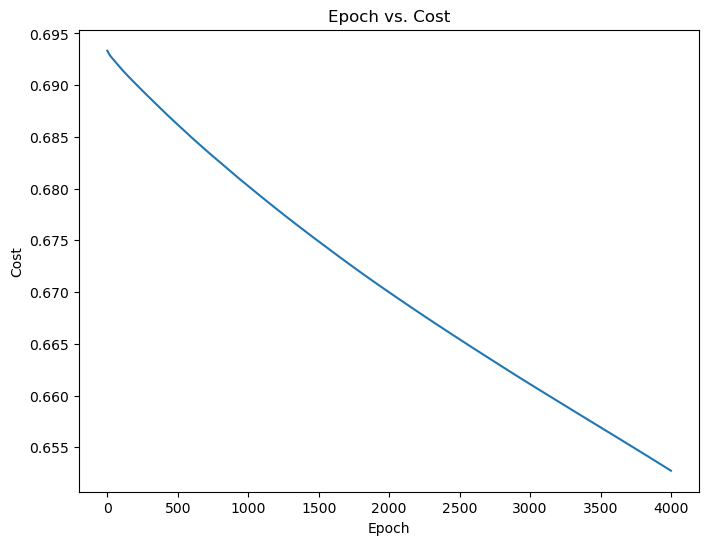

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.0005
_____________________________________________________________________
Epoch: 0; Cost: 0.675269223090208, Duration: 0.03 S
Epoch: 200; Cost: 0.6220306034157017, Duration: 0.01 S
Epoch: 400; Cost: 0.5991630966196595, Duration: 0.011 S
Epoch: 600; Cost: 0.5796426139336786, Duration: 0.011 S
Epoch: 800; Cost: 0.5619549949346199, Duration: 0.011 S
Epoch: 1000; Cost: 0.5463605908791599, Duration: 0.01 S
Epoch: 1200; Cost: 0.5329646511123431, Duration: 0.012 S
Epoch: 1400; Cost: 0.5207765171136853, Duration: 0.01 S
Epoch: 1600; Cost: 0.5093145256075663, Duration: 0.01 S
Epoch: 1800; Cost: 0.49815337235296, Duration: 0.01 S
Epoch: 2000; Cost: 0.4874145344063638, Duration: 0.01 S
Epoch: 2200; Cost: 0.4769926508421914, Duration: 0.01 S
Epoch: 2400; Cost: 0.46683010608222336, Duration: 0.01 S
Epoch: 2600; Cost: 0.456947675683148, Duration: 0.012 S
Epoch: 2800

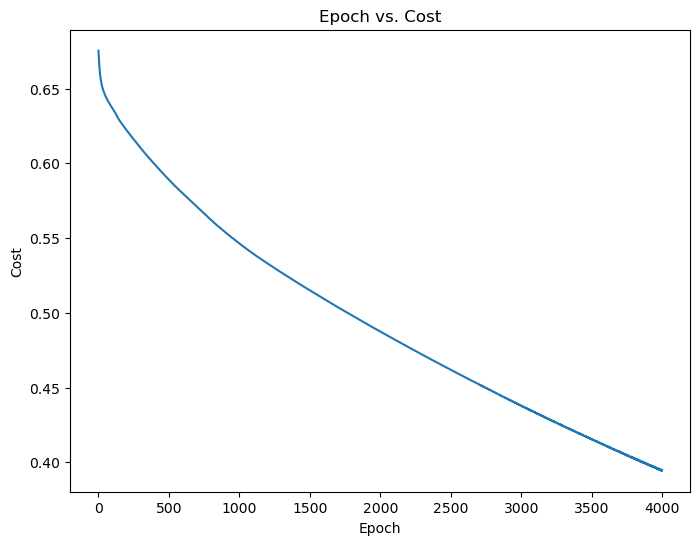

_____________________________________________________________________
NN_Model with 4 layers; Number of Epochs: 4000; Learning Rate: 0.0005
_____________________________________________________________________
Epoch: 0; Cost: 0.693244301489931, Duration: 0.018 S
Epoch: 200; Cost: 0.6908056220953567, Duration: 0.01 S
Epoch: 400; Cost: 0.6885450789032576, Duration: 0.01 S
Epoch: 600; Cost: 0.6864100145734764, Duration: 0.01 S
Epoch: 800; Cost: 0.684379738885692, Duration: 0.01 S
Epoch: 1000; Cost: 0.6824484018923879, Duration: 0.01 S
Epoch: 1200; Cost: 0.6806111400778744, Duration: 0.013 S
Epoch: 1400; Cost: 0.6788633239269616, Duration: 0.01 S
Epoch: 1600; Cost: 0.6772005478130124, Duration: 0.01 S
Epoch: 1800; Cost: 0.6756186201574637, Duration: 0.01 S
Epoch: 2000; Cost: 0.6741135538767253, Duration: 0.014 S
Epoch: 2200; Cost: 0.6726815571283054, Duration: 0.009 S
Epoch: 2400; Cost: 0.6713190243644941, Duration: 0.009 S
Epoch: 2600; Cost: 0.6700225276988581, Duration: 0.009 S
Epoch: 28

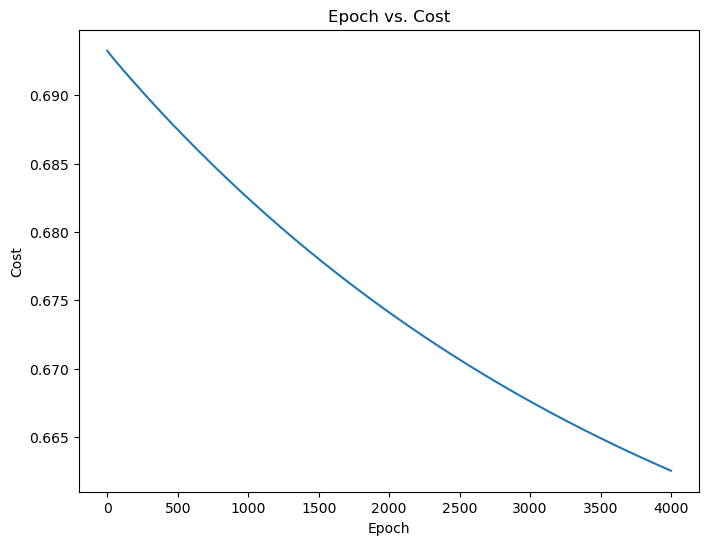

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.001
_____________________________________________________________________
Epoch: 0; Cost: 0.6932195073562671, Duration: 0.015 S
Epoch: 200; Cost: 0.6879410622587953, Duration: 0.01 S
Epoch: 400; Cost: 0.6832141527632373, Duration: 0.009 S
Epoch: 600; Cost: 0.6789185620062587, Duration: 0.009 S
Epoch: 800; Cost: 0.6750386076313617, Duration: 0.01 S
Epoch: 1000; Cost: 0.6714840574507268, Duration: 0.008 S
Epoch: 1200; Cost: 0.6681831483162777, Duration: 0.01 S
Epoch: 1400; Cost: 0.6650115476661091, Duration: 0.009 S
Epoch: 1600; Cost: 0.6620221427108529, Duration: 0.008 S
Epoch: 1800; Cost: 0.6577394474493872, Duration: 0.008 S
Epoch: 2000; Cost: 0.6531373608200163, Duration: 0.008 S
Epoch: 2200; Cost: 0.6485084909843511, Duration: 0.008 S
Epoch: 2400; Cost: 0.6436534637956502, Duration: 0.008 S
Epoch: 2600; Cost: 0.6383938247315717, Duration: 0.008 S
Epo

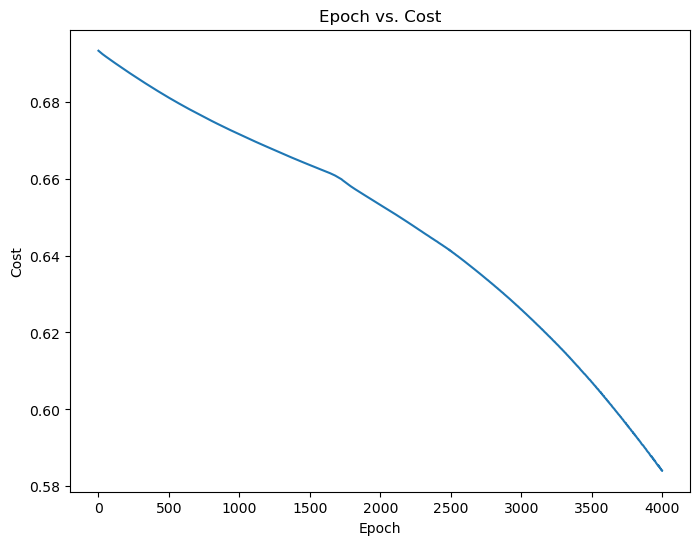

_____________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 4000; Learning Rate: 0.001
_____________________________________________________________________
Epoch: 0; Cost: 0.693330159998475, Duration: 0.025 S
Epoch: 200; Cost: 0.6874450429554401, Duration: 0.011 S
Epoch: 400; Cost: 0.6825212343374495, Duration: 0.01 S
Epoch: 600; Cost: 0.6780428994026844, Duration: 0.011 S
Epoch: 800; Cost: 0.673895990546228, Duration: 0.011 S
Epoch: 1000; Cost: 0.6700025303200294, Duration: 0.019 S
Epoch: 1200; Cost: 0.6663450002992395, Duration: 0.011 S
Epoch: 1400; Cost: 0.6628668310007545, Duration: 0.012 S
Epoch: 1600; Cost: 0.6595133724745542, Duration: 0.014 S
Epoch: 1800; Cost: 0.6562431802234866, Duration: 0.011 S
Epoch: 2000; Cost: 0.6529964137036479, Duration: 0.012 S
Epoch: 2200; Cost: 0.6496969431387309, Duration: 0.013 S
Epoch: 2400; Cost: 0.6462897721822309, Duration: 0.011 S
Epoch: 2600; Cost: 0.6427299779222055, Duration: 0.01 S
Epoc

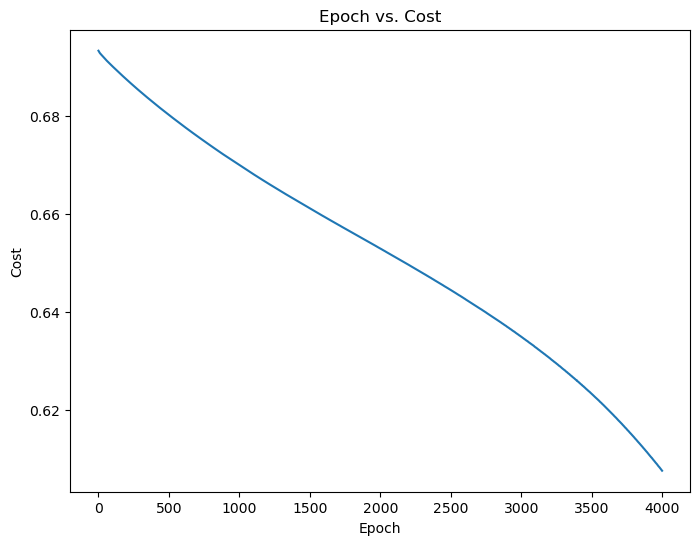

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.001
_____________________________________________________________________
Epoch: 0; Cost: 0.675269223090208, Duration: 0.017 S
Epoch: 200; Cost: 0.5991759712265403, Duration: 0.011 S
Epoch: 400; Cost: 0.5620187836139915, Duration: 0.011 S
Epoch: 600; Cost: 0.5330292076832903, Duration: 0.011 S
Epoch: 800; Cost: 0.5094366160504877, Duration: 0.012 S
Epoch: 1000; Cost: 0.4875152332683556, Duration: 0.013 S
Epoch: 1200; Cost: 0.46696714345948853, Duration: 0.012 S
Epoch: 1400; Cost: 0.44751679307378944, Duration: 0.011 S
Epoch: 1600; Cost: 0.42949609077385426, Duration: 0.011 S
Epoch: 1800; Cost: 0.41152913715822104, Duration: 0.01 S
Epoch: 2000; Cost: 0.3947564820295727, Duration: 0.011 S
Epoch: 2200; Cost: 0.3792118947508358, Duration: 0.013 S
Epoch: 2400; Cost: 0.36424582759121227, Duration: 0.01 S
Epoch: 2600; Cost: 0.35351944934593416, Duration: 0.01 

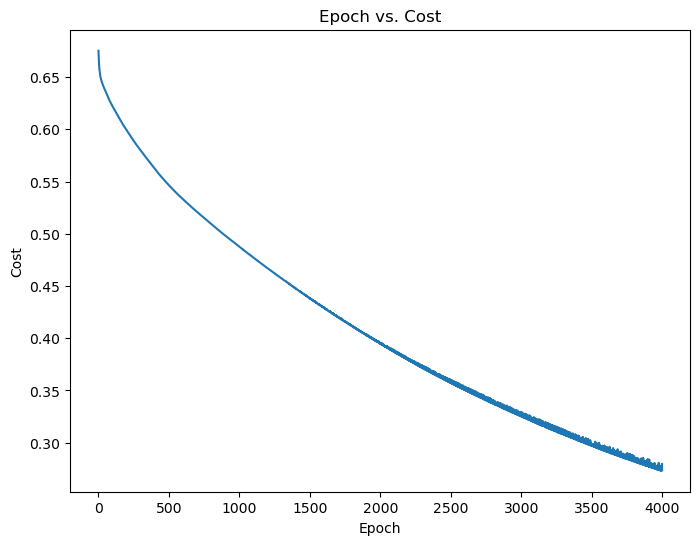

_____________________________________________________________________
NN_Model with 4 layers; Number of Epochs: 4000; Learning Rate: 0.001
_____________________________________________________________________
Epoch: 0; Cost: 0.693244301489931, Duration: 0.015 S
Epoch: 200; Cost: 0.688544615524888, Duration: 0.009 S
Epoch: 400; Cost: 0.6843792453084908, Duration: 0.009 S
Epoch: 600; Cost: 0.6806104697033336, Duration: 0.009 S
Epoch: 800; Cost: 0.6771997388495476, Duration: 0.009 S
Epoch: 1000; Cost: 0.6741126388152257, Duration: 0.011 S
Epoch: 1200; Cost: 0.6713180307074644, Duration: 0.011 S
Epoch: 1400; Cost: 0.6687877595004479, Duration: 0.009 S
Epoch: 1600; Cost: 0.6664963827607212, Duration: 0.009 S
Epoch: 1800; Cost: 0.664420919490507, Duration: 0.009 S
Epoch: 2000; Cost: 0.6625406188025104, Duration: 0.009 S
Epoch: 2200; Cost: 0.6608367477793415, Duration: 0.011 S
Epoch: 2400; Cost: 0.6592923976262461, Duration: 0.009 S
Epoch: 2600; Cost: 0.6578923070712137, Duration: 0.011 S
Epo

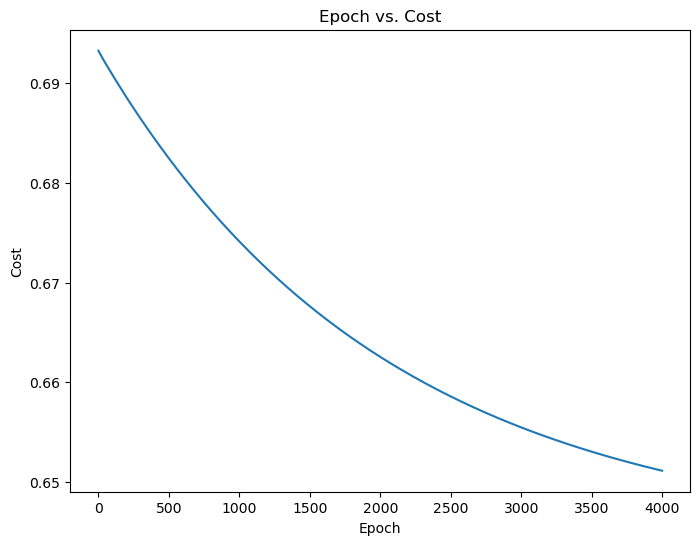

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.003
_____________________________________________________________________
Epoch: 0; Cost: 0.6932195073562671, Duration: 0.014 S
Epoch: 200; Cost: 0.678913397038707, Duration: 0.009 S
Epoch: 400; Cost: 0.6681664443144123, Duration: 0.008 S
Epoch: 600; Cost: 0.6575661540300076, Duration: 0.008 S
Epoch: 800; Cost: 0.6435306504350814, Duration: 0.008 S
Epoch: 1000; Cost: 0.6254202873174851, Duration: 0.008 S
Epoch: 1200; Cost: 0.6018022041219044, Duration: 0.008 S
Epoch: 1400; Cost: 0.5721059179828788, Duration: 0.01 S
Epoch: 1600; Cost: 0.5369747458429317, Duration: 0.008 S
Epoch: 1800; Cost: 0.5010947004053525, Duration: 0.009 S
Epoch: 2000; Cost: 0.4612749135573777, Duration: 0.008 S
Epoch: 2200; Cost: 0.42552767115993284, Duration: 0.008 S
Epoch: 2400; Cost: 0.38748746879467644, Duration: 0.008 S
Epoch: 2600; Cost: 0.35277774042463156, Duration: 0.008 S

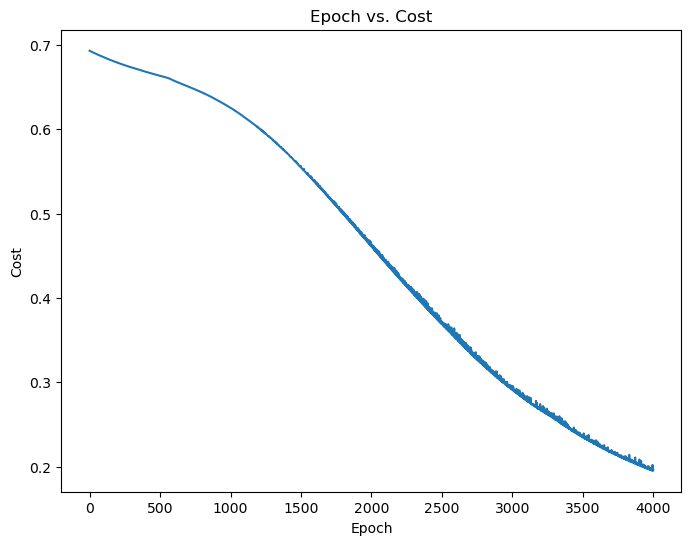

_____________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 4000; Learning Rate: 0.003
_____________________________________________________________________
Epoch: 0; Cost: 0.693330159998475, Duration: 0.02 S
Epoch: 200; Cost: 0.6780279706233772, Duration: 0.011 S
Epoch: 400; Cost: 0.6663447043251569, Duration: 0.01 S
Epoch: 600; Cost: 0.6562047710226562, Duration: 0.011 S
Epoch: 800; Cost: 0.6462009259222284, Duration: 0.011 S
Epoch: 1000; Cost: 0.6348265068030449, Duration: 0.013 S
Epoch: 1200; Cost: 0.6204212959881386, Duration: 0.011 S
Epoch: 1400; Cost: 0.5991811218513383, Duration: 0.011 S
Epoch: 1600; Cost: 0.5689425434525504, Duration: 0.011 S
Epoch: 1800; Cost: 0.5328579570636698, Duration: 0.011 S
Epoch: 2000; Cost: 0.4929213766126303, Duration: 0.011 S
Epoch: 2200; Cost: 0.4582053155087953, Duration: 0.011 S
Epoch: 2400; Cost: 0.42527778367268604, Duration: 0.014 S
Epoch: 2600; Cost: 0.4005570130991131, Duration: 0.011 S
Ep

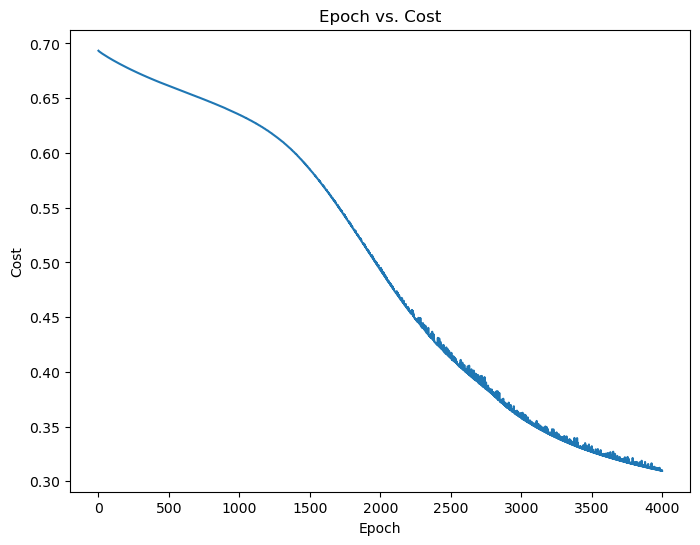

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.003
_____________________________________________________________________
Epoch: 0; Cost: 0.675269223090208, Duration: 0.019 S
Epoch: 200; Cost: 0.5328938874116451, Duration: 0.011 S
Epoch: 400; Cost: 0.4675138800793349, Duration: 0.012 S
Epoch: 600; Cost: 0.4197074169361338, Duration: 0.011 S
Epoch: 800; Cost: 0.37338864057000143, Duration: 0.011 S
Epoch: 1000; Cost: 0.33493255043977604, Duration: 0.013 S
Epoch: 1200; Cost: 0.2988082200008149, Duration: 0.011 S
Epoch: 1400; Cost: 0.2691606680205103, Duration: 0.011 S
Epoch: 1600; Cost: 0.2614953045535546, Duration: 0.011 S
Epoch: 1800; Cost: 0.22529239032402715, Duration: 0.011 S
Epoch: 2000; Cost: 0.20884835824855338, Duration: 0.012 S
Epoch: 2200; Cost: 0.19438804622131228, Duration: 0.011 S
Epoch: 2400; Cost: 0.18402876220546904, Duration: 0.013 S
Epoch: 2600; Cost: 0.17278798699311165, Duration: 0.

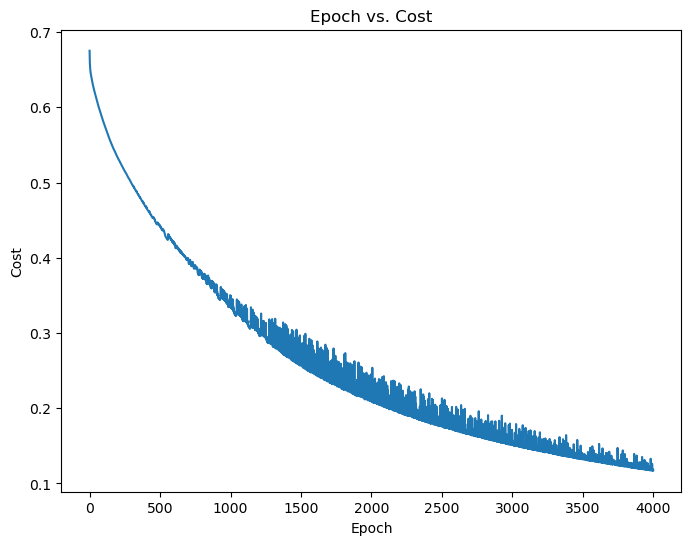

_____________________________________________________________________
NN_Model with 4 layers; Number of Epochs: 4000; Learning Rate: 0.003
_____________________________________________________________________
Epoch: 0; Cost: 0.693244301489931, Duration: 0.016 S
Epoch: 200; Cost: 0.6806077844499183, Duration: 0.01 S
Epoch: 400; Cost: 0.6713140527441703, Duration: 0.01 S
Epoch: 600; Cost: 0.6644164968119153, Duration: 0.009 S
Epoch: 800; Cost: 0.6592880205622687, Duration: 0.012 S
Epoch: 1000; Cost: 0.6554670808522981, Duration: 0.009 S
Epoch: 1200; Cost: 0.6526142857986515, Duration: 0.013 S
Epoch: 1400; Cost: 0.6504798931932686, Duration: 0.013 S
Epoch: 1600; Cost: 0.6488798233136539, Duration: 0.015 S
Epoch: 1800; Cost: 0.647678093472918, Duration: 0.009 S
Epoch: 2000; Cost: 0.6467740005177307, Duration: 0.009 S
Epoch: 2200; Cost: 0.6460927753874002, Duration: 0.012 S
Epoch: 2400; Cost: 0.6455787628567382, Duration: 0.01 S
Epoch: 2600; Cost: 0.6451904341911623, Duration: 0.01 S
Epoch:

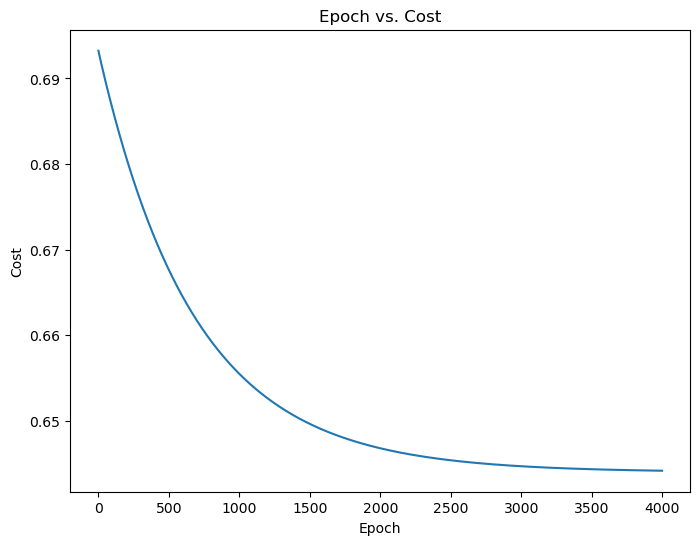

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.006
_____________________________________________________________________
Epoch: 0; Cost: 0.6932195073562671, Duration: 0.013 S
Epoch: 200; Cost: 0.6681269066290302, Duration: 0.008 S
Epoch: 400; Cost: 0.6431467892464082, Duration: 0.01 S
Epoch: 600; Cost: 0.6015143774668307, Duration: 0.008 S
Epoch: 800; Cost: 0.5381267277996041, Duration: 0.008 S
Epoch: 1000; Cost: 0.46485918527527503, Duration: 0.008 S
Epoch: 1200; Cost: 0.3854578190371548, Duration: 0.015 S
Epoch: 1400; Cost: 0.3204308962135792, Duration: 0.014 S
Epoch: 1600; Cost: 0.26343696734061656, Duration: 0.009 S
Epoch: 1800; Cost: 0.2224257271366122, Duration: 0.008 S
Epoch: 2000; Cost: 0.19261182984129863, Duration: 0.008 S
Epoch: 2200; Cost: 0.17194124717361856, Duration: 0.008 S
Epoch: 2400; Cost: 0.15040448344664029, Duration: 0.008 S
Epoch: 2600; Cost: 0.1363579652462303, Duration: 0.00

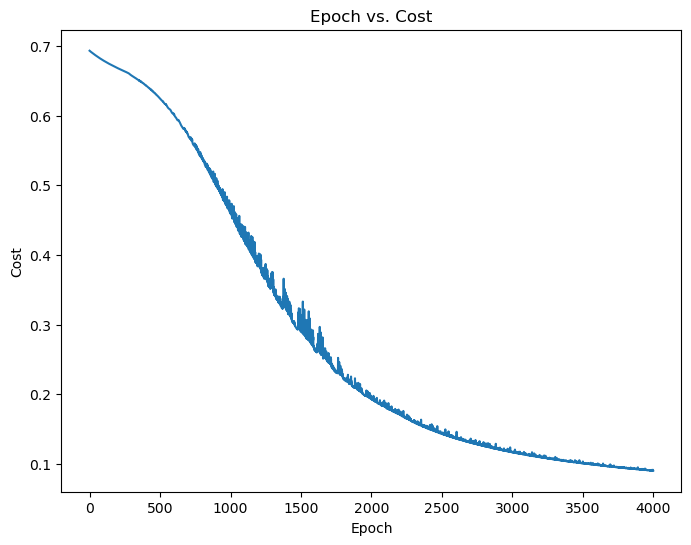

_____________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 4000; Learning Rate: 0.006
_____________________________________________________________________
Epoch: 0; Cost: 0.693330159998475, Duration: 0.02 S
Epoch: 200; Cost: 0.6663451382568525, Duration: 0.011 S
Epoch: 400; Cost: 0.6460935202840065, Duration: 0.014 S
Epoch: 600; Cost: 0.6162170719339137, Duration: 0.011 S
Epoch: 800; Cost: 0.5548425122209394, Duration: 0.01 S
Epoch: 1000; Cost: 0.48026800982613643, Duration: 0.011 S
Epoch: 1200; Cost: 0.4029390646231325, Duration: 0.011 S
Epoch: 1400; Cost: 0.3321133853304996, Duration: 0.011 S
Epoch: 1600; Cost: 0.2533679948268903, Duration: 0.015 S
Epoch: 1800; Cost: 0.20970083773703457, Duration: 0.012 S
Epoch: 2000; Cost: 0.1830097228425602, Duration: 0.012 S
Epoch: 2200; Cost: 0.16518057542044304, Duration: 0.012 S
Epoch: 2400; Cost: 0.15061338009918548, Duration: 0.012 S
Epoch: 2600; Cost: 0.13974109436163507, Duration: 0.011 

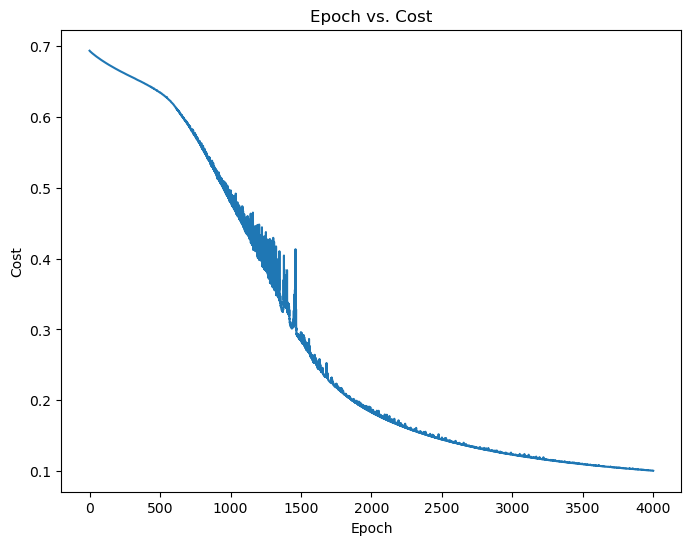

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.006
_____________________________________________________________________
Epoch: 0; Cost: 0.675269223090208, Duration: 0.02 S
Epoch: 200; Cost: 0.4752718792885466, Duration: 0.016 S
Epoch: 400; Cost: 0.40635488888967475, Duration: 0.011 S
Epoch: 600; Cost: 0.3337765042685026, Duration: 0.011 S
Epoch: 800; Cost: 0.2686312382015247, Duration: 0.011 S
Epoch: 1000; Cost: 0.22907766902814533, Duration: 0.017 S
Epoch: 1200; Cost: 0.20530687732303488, Duration: 0.011 S
Epoch: 1400; Cost: 0.17234795974731543, Duration: 0.01 S
Epoch: 1600; Cost: 0.1539516848812667, Duration: 0.011 S
Epoch: 1800; Cost: 0.1759080948323627, Duration: 0.01 S
Epoch: 2000; Cost: 0.12413321584547847, Duration: 0.011 S
Epoch: 2200; Cost: 0.12037301774303805, Duration: 0.015 S
Epoch: 2400; Cost: 0.1064176924260785, Duration: 0.011 S
Epoch: 2600; Cost: 0.09338831915280947, Duration: 0.011

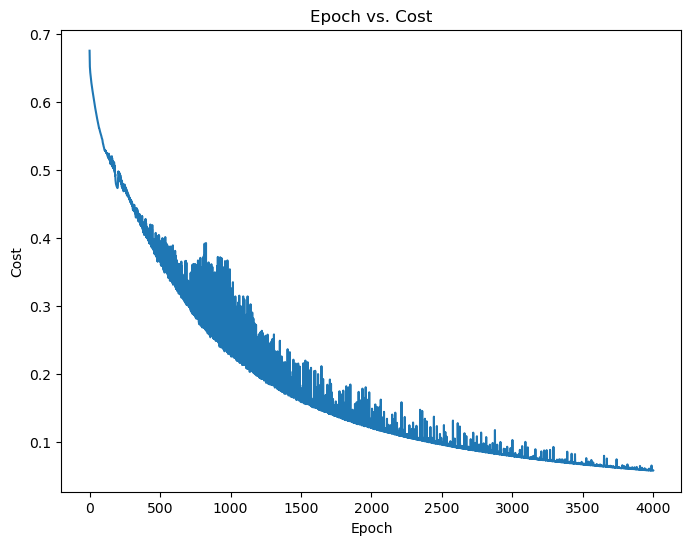

_____________________________________________________________________
NN_Model with 4 layers; Number of Epochs: 4000; Learning Rate: 0.006
_____________________________________________________________________
Epoch: 0; Cost: 0.693244301489931, Duration: 0.016 S
Epoch: 200; Cost: 0.6713080772053195, Duration: 0.009 S
Epoch: 400; Cost: 0.6592814493211174, Duration: 0.009 S
Epoch: 600; Cost: 0.6526088266581285, Duration: 0.009 S
Epoch: 800; Cost: 0.64887576007461, Duration: 0.013 S
Epoch: 1000; Cost: 0.6467711444450008, Duration: 0.011 S
Epoch: 1200; Cost: 0.6455768233996093, Duration: 0.01 S
Epoch: 1400; Cost: 0.6448954433975896, Duration: 0.017 S
Epoch: 1600; Cost: 0.6445050452424378, Duration: 0.011 S
Epoch: 1800; Cost: 0.6442806155310976, Duration: 0.01 S
Epoch: 2000; Cost: 0.6441512598442005, Duration: 0.014 S
Epoch: 2200; Cost: 0.64407655179326, Duration: 0.013 S
Epoch: 2400; Cost: 0.6440333377311428, Duration: 0.014 S
Epoch: 2600; Cost: 0.6440083111110787, Duration: 0.009 S
Epoch: 

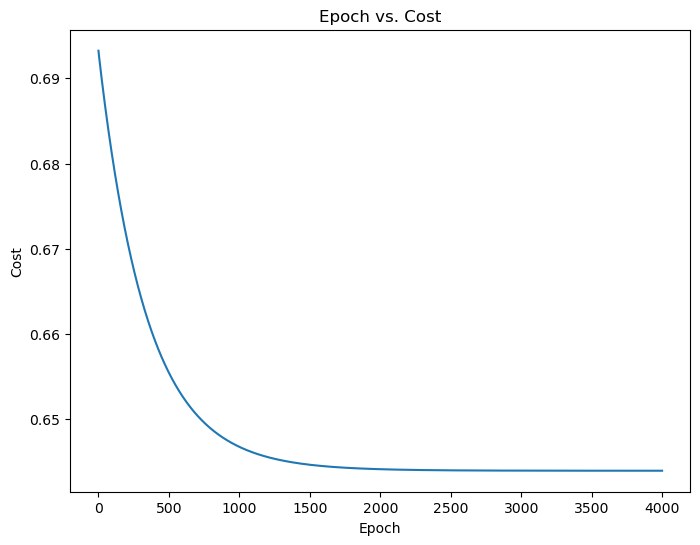

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.008
_____________________________________________________________________
Epoch: 0; Cost: 0.6932195073562671, Duration: 0.014 S
Epoch: 200; Cost: 0.661893955888625, Duration: 0.008 S
Epoch: 400; Cost: 0.6166192517343843, Duration: 0.008 S
Epoch: 600; Cost: 0.537729046030877, Duration: 0.008 S
Epoch: 800; Cost: 0.43885454365922666, Duration: 0.009 S
Epoch: 1000; Cost: 0.35271782789409434, Duration: 0.011 S
Epoch: 1200; Cost: 0.2734254949284123, Duration: 0.013 S
Epoch: 1400; Cost: 0.21639415320052502, Duration: 0.009 S
Epoch: 1600; Cost: 0.17980333000129015, Duration: 0.008 S
Epoch: 1800; Cost: 0.1529788451335402, Duration: 0.008 S
Epoch: 2000; Cost: 0.13369985748203156, Duration: 0.008 S
Epoch: 2200; Cost: 0.1211272402942811, Duration: 0.008 S
Epoch: 2400; Cost: 0.10978606371771306, Duration: 0.013 S
Epoch: 2600; Cost: 0.10215529260666471, Duration: 0.0

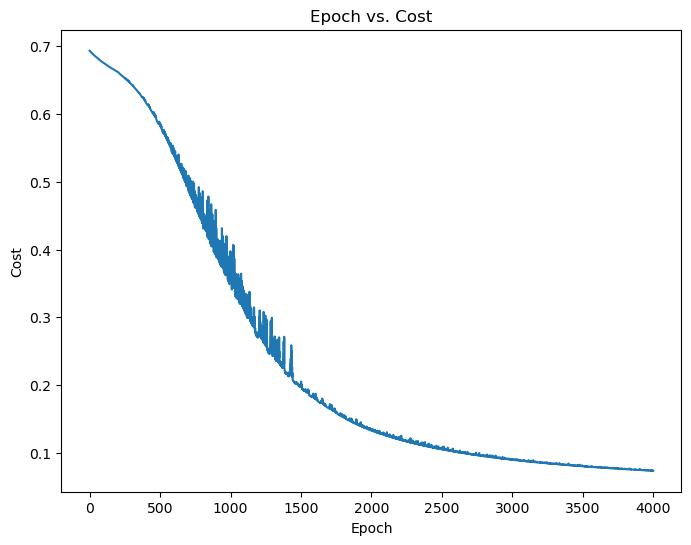

_____________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 4000; Learning Rate: 0.008
_____________________________________________________________________
Epoch: 0; Cost: 0.693330159998475, Duration: 0.021 S
Epoch: 200; Cost: 0.6595044832994701, Duration: 0.011 S
Epoch: 400; Cost: 0.6274538325760504, Duration: 0.011 S
Epoch: 600; Cost: 0.5566312521047205, Duration: 0.011 S
Epoch: 800; Cost: 0.4715321771729721, Duration: 0.01 S
Epoch: 1000; Cost: 0.3917502782676198, Duration: 0.01 S
Epoch: 1200; Cost: 0.3220723692410367, Duration: 0.011 S
Epoch: 1400; Cost: 0.27047331831477534, Duration: 0.011 S
Epoch: 1600; Cost: 0.23262649683373676, Duration: 0.013 S
Epoch: 1800; Cost: 0.20923628721351487, Duration: 0.014 S
Epoch: 2000; Cost: 0.15985683327137598, Duration: 0.011 S
Epoch: 2200; Cost: 0.13740902198592803, Duration: 0.012 S
Epoch: 2400; Cost: 0.12592857633894833, Duration: 0.012 S
Epoch: 2600; Cost: 0.11693426544507743, Duration: 0.01

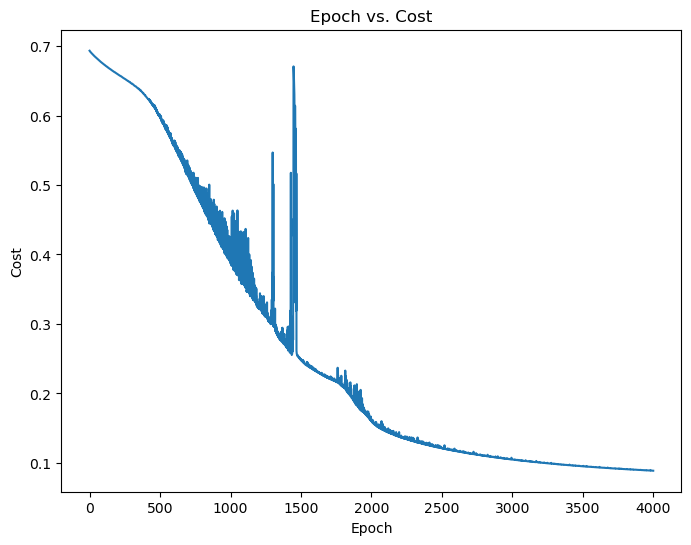

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.008
_____________________________________________________________________
Epoch: 0; Cost: 0.675269223090208, Duration: 0.019 S
Epoch: 200; Cost: 0.4817753036656363, Duration: 0.013 S
Epoch: 400; Cost: 0.3755860706217783, Duration: 0.01 S
Epoch: 600; Cost: 0.3122284471799666, Duration: 0.01 S
Epoch: 800; Cost: 0.2626098413210138, Duration: 0.011 S
Epoch: 1000; Cost: 0.20492357256710667, Duration: 0.01 S
Epoch: 1200; Cost: 0.16150222615978163, Duration: 0.011 S
Epoch: 1400; Cost: 0.13903159355970066, Duration: 0.011 S
Epoch: 1600; Cost: 0.12056397637334552, Duration: 0.011 S
Epoch: 1800; Cost: 0.11894293021347686, Duration: 0.011 S
Epoch: 2000; Cost: 0.09418843702273572, Duration: 0.012 S
Epoch: 2200; Cost: 0.0888721804847249, Duration: 0.011 S
Epoch: 2400; Cost: 0.07799625688393368, Duration: 0.011 S
Epoch: 2600; Cost: 0.07020210271466899, Duration: 0.01

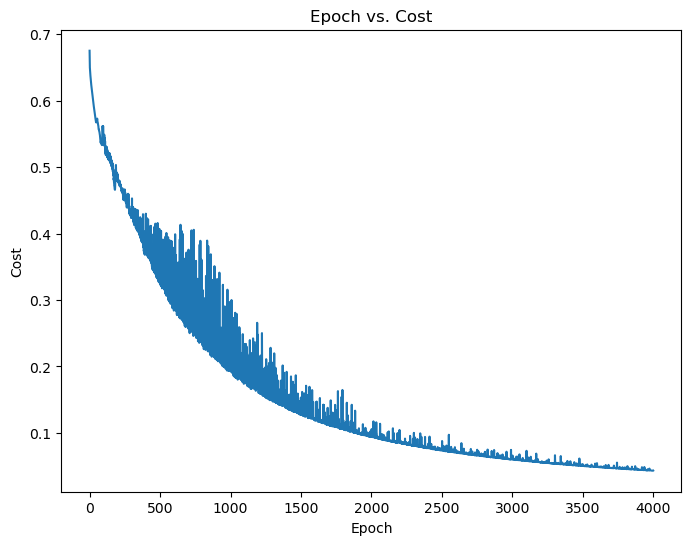

_____________________________________________________________________
NN_Model with 4 layers; Number of Epochs: 4000; Learning Rate: 0.008
_____________________________________________________________________
Epoch: 0; Cost: 0.693244301489931, Duration: 0.018 S
Epoch: 200; Cost: 0.6664811632002743, Duration: 0.009 S
Epoch: 400; Cost: 0.6544126511275795, Duration: 0.01 S
Epoch: 600; Cost: 0.64887305047556, Duration: 0.009 S
Epoch: 800; Cost: 0.6462946577964208, Duration: 0.011 S
Epoch: 1000; Cost: 0.6450808427931717, Duration: 0.012 S
Epoch: 1200; Cost: 0.6445044852204834, Duration: 0.009 S
Epoch: 1400; Cost: 0.6442290860417335, Duration: 0.011 S
Epoch: 1600; Cost: 0.6440968978873032, Duration: 0.01 S
Epoch: 1800; Cost: 0.6440332457632553, Duration: 0.01 S
Epoch: 2000; Cost: 0.6440025262978314, Duration: 0.009 S
Epoch: 2200; Cost: 0.6439876771050523, Duration: 0.009 S
Epoch: 2400; Cost: 0.643980491320575, Duration: 0.014 S
Epoch: 2600; Cost: 0.6439770112935551, Duration: 0.009 S
Epoch: 

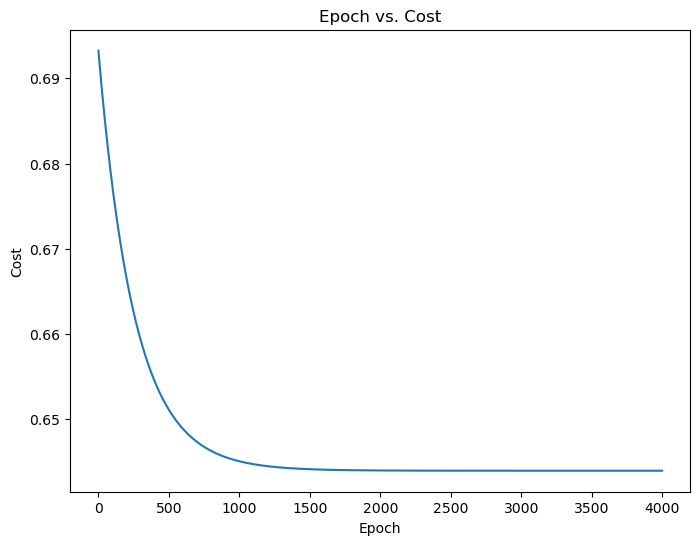

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.01
_____________________________________________________________________
Epoch: 0; Cost: 0.6932195073562671, Duration: 0.012 S
Epoch: 200; Cost: 0.6523814047912928, Duration: 0.008 S
Epoch: 400; Cost: 0.5816117557481968, Duration: 0.01 S
Epoch: 600; Cost: 0.474877305270291, Duration: 0.008 S
Epoch: 800; Cost: 0.35960369529198416, Duration: 0.008 S
Epoch: 1000; Cost: 0.27109325086371255, Duration: 0.008 S
Epoch: 1200; Cost: 0.21651730341303732, Duration: 0.008 S
Epoch: 1400; Cost: 0.16534094285538203, Duration: 0.008 S
Epoch: 1600; Cost: 0.1377898240256716, Duration: 0.01 S
Epoch: 1800; Cost: 0.11996724913357598, Duration: 0.01 S
Epoch: 2000; Cost: 0.10935889996591448, Duration: 0.01 S
Epoch: 2200; Cost: 0.0978818685754623, Duration: 0.008 S
Epoch: 2400; Cost: 0.0915523036450589, Duration: 0.008 S
Epoch: 2600; Cost: 0.08527466809287568, Duration: 0.008 S

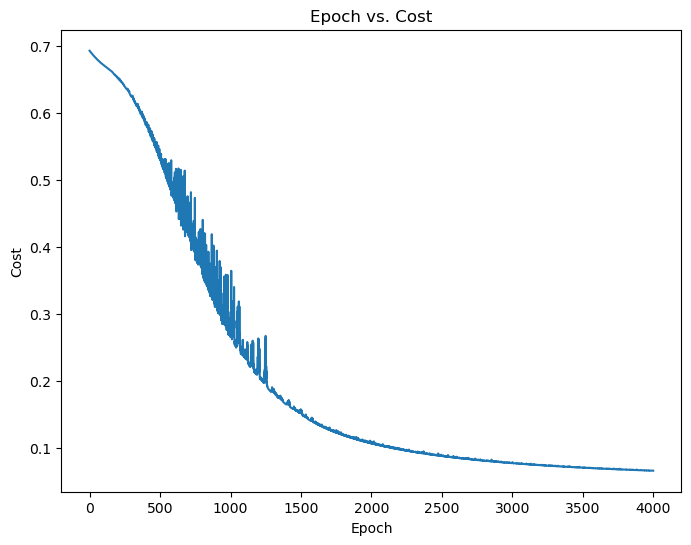

_____________________________________________________________________
NN_Model with 5 layers; Number of Epochs: 4000; Learning Rate: 0.01
_____________________________________________________________________
Epoch: 0; Cost: 0.693330159998475, Duration: 0.022 S
Epoch: 200; Cost: 0.6528708063139559, Duration: 0.011 S
Epoch: 400; Cost: 0.6000250587752712, Duration: 0.012 S
Epoch: 600; Cost: 0.502356078250653, Duration: 0.011 S
Epoch: 800; Cost: 0.40411910197369555, Duration: 0.011 S
Epoch: 1000; Cost: 0.322315899579409, Duration: 0.013 S
Epoch: 1200; Cost: 0.24930268794402938, Duration: 0.011 S
Epoch: 1400; Cost: 0.22002203518338576, Duration: 0.011 S
Epoch: 1600; Cost: 0.19282744252841605, Duration: 0.01 S
Epoch: 1800; Cost: 0.6524274716210121, Duration: 0.011 S
Epoch: 2000; Cost: 0.6414557436338285, Duration: 0.011 S
Epoch: 2200; Cost: 0.6027938168502255, Duration: 0.016 S
Epoch: 2400; Cost: 0.5104721087916863, Duration: 0.013 S
Epoch: 2600; Cost: 0.41972040608398253, Duration: 0.011 S


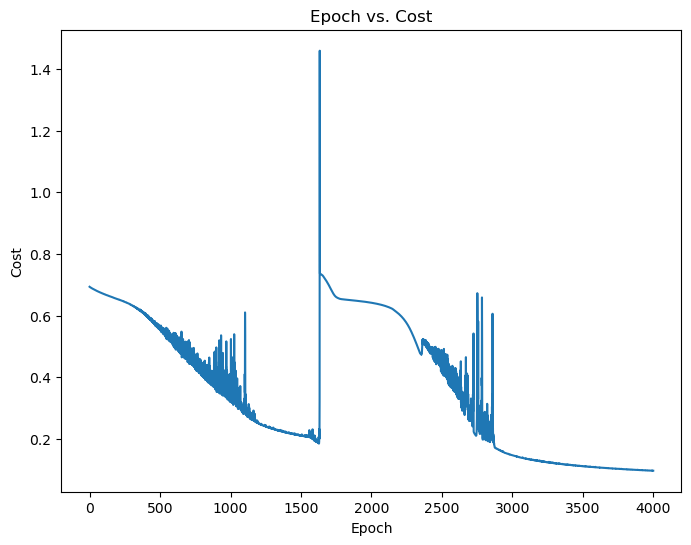

_____________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 4000; Learning Rate: 0.01
_____________________________________________________________________
Epoch: 0; Cost: 0.675269223090208, Duration: 0.016 S
Epoch: 200; Cost: 0.4652510254923212, Duration: 0.011 S
Epoch: 400; Cost: 0.399458340723474, Duration: 0.01 S
Epoch: 600; Cost: 0.2775593726191427, Duration: 0.01 S
Epoch: 800; Cost: 0.23516490986167427, Duration: 0.014 S
Epoch: 1000; Cost: 0.18670500471056828, Duration: 0.01 S
Epoch: 1200; Cost: 0.1566070575043653, Duration: 0.012 S
Epoch: 1400; Cost: 0.11730887448553745, Duration: 0.011 S
Epoch: 1600; Cost: 0.096524055106755, Duration: 0.011 S
Epoch: 1800; Cost: 0.08495278198672575, Duration: 0.011 S
Epoch: 2000; Cost: 0.07742902972936803, Duration: 0.014 S
Epoch: 2200; Cost: 0.06821913623348039, Duration: 0.011 S
Epoch: 2400; Cost: 0.06122979129179123, Duration: 0.011 S
Epoch: 2600; Cost: 0.05621448054143577, Duration: 0.014 S

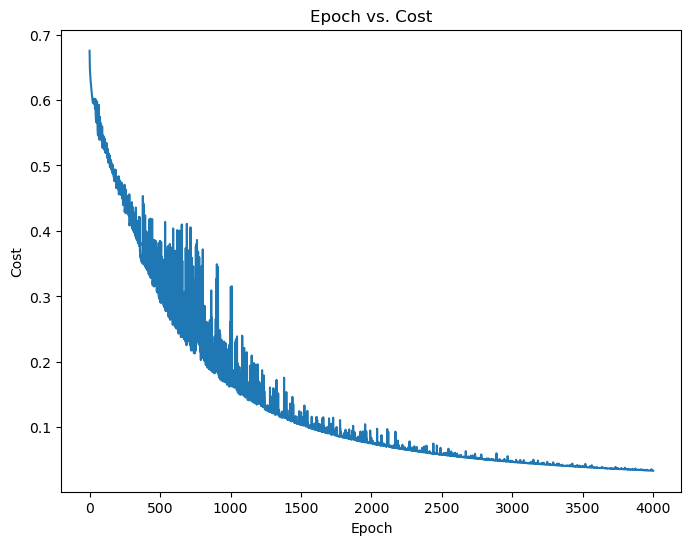

_____________________________________________________________________
NN_Model with 4 layers; Number of Epochs: 4000; Learning Rate: 0.01
_____________________________________________________________________
Epoch: 0; Cost: 0.693244301489931, Duration: 0.014 S
Epoch: 200; Cost: 0.6625205804107323, Duration: 0.009 S
Epoch: 400; Cost: 0.6511123880227815, Duration: 0.009 S
Epoch: 600; Cost: 0.6467673369755857, Duration: 0.01 S
Epoch: 800; Cost: 0.645079857796942, Duration: 0.01 S
Epoch: 1000; Cost: 0.6444151542832026, Duration: 0.011 S
Epoch: 1200; Cost: 0.6441507988434312, Duration: 0.01 S
Epoch: 1400; Cost: 0.6440449964236539, Duration: 0.009 S
Epoch: 1600; Cost: 0.6440024771728329, Duration: 0.015 S
Epoch: 1800; Cost: 0.6439853445771492, Duration: 0.009 S
Epoch: 2000; Cost: 0.6439784295151944, Duration: 0.009 S
Epoch: 2200; Cost: 0.6439756354347018, Duration: 0.009 S
Epoch: 2400; Cost: 0.6439745056867383, Duration: 0.009 S
Epoch: 2600; Cost: 0.6439740486876744, Duration: 0.009 S
Epoch:

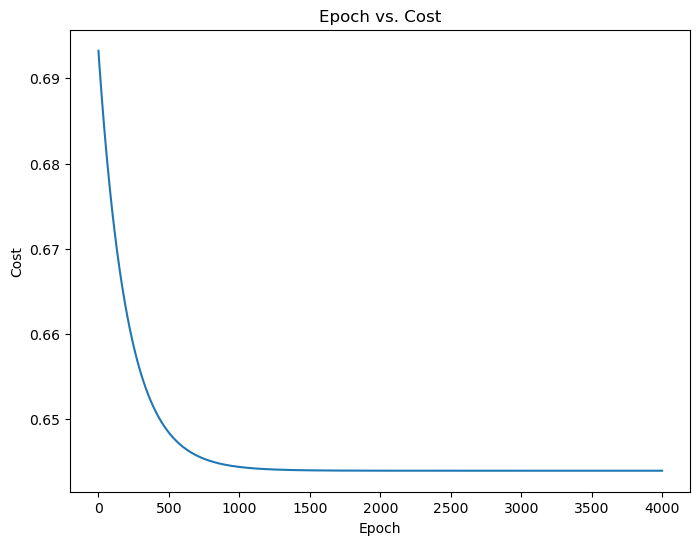

In [6]:
learning_rates = [0.0001, 0.0005, 0.001, 0.003, 0.006, 0.008, 0.01]
num_hs = [[5, 2], [20, 10, 8, 4], [20, 6], [10, 6, 3]]

for a in learning_rates:
    for l in num_hs:
        model = DeepFeedForward(
            hidden_activation="relu",
            output_activation="sigmoid",
            print_cost=True,
            visualize_cost=True,
            epsilon=200,
            sigma=1e-12,
            seed=42
        )
        model.nn_model(
            X_train=X_train,
            Y_train=Y_train,
            num_hidden_units=l,
            X_validation=None,
            Y_validation=None,
            X_test=X_test,
            Y_test=Y_test,
            hidden_activation="relu",
            output_activation="sigmoid",
            epochs=4000,
            learning_rate=a,
            accuracy=True
        )